# Week 2

In Week 1, you implemented a perceptron with a hard step decision.

In this lab, you will build and train a neural network on a dataset named Iris.

Your model will:
1. take the four Iris measurements as input,
2. compute a hidden representation,
3. output class scores for the three Iris species,
4. learn using multi-class cross-entropy loss.

This is the foundation of modern neural network training.

This lab has **two tasks**:
- **Task A: Model from Scratch**
- **Task B: Rebuild the Model with `nn.Module`**

Task A is largely provided for you. Your goal is to study the code carefully and understand how each component works.

Task B is more challenging and requires you to implement a larger portion of the solution yourself. You are expected to apply the concepts learned from Task A and complete the code independently.

**Submission is required for this lab, it worths 3 points. Please ensure that all cells have been run before submitting so the outputs are clearly visible; otherwise, your score may be affected.**

---

### About the Iris Dataset

We will use the Iris dataset. It is a classic machine learning dataset with **150 samples** from **3 flower species**: Setosa, Versicolor, and Virginica.

Each sample has **4 measurements**:
- sepal length
- sepal width
- petal length
- petal width

The task is a multi-class classification problem. Let's first observe the dataset.

In [ ]:
import pandas as pd
from sklearn.datasets import load_iris

# Load the Iris dataset
iris = load_iris()

# Put the data into a table so we can inspect it more easily
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names) # Create a DataFrame with the feature data and column names
iris_df["species"] = [iris.target_names[i] for i in iris.target] # Add a column for the species names based on the target labels

# Print out some basic information about the dataset
print(f"Samples: {iris.data.shape[0]}")
print(f"Features: {iris.data.shape[1]}")
print(f"Classes: {list(iris.target_names)}")

# Display the first few rows of the dataset
print("\nFirst five rows:")
print(iris_df.head().to_string(index=False))

# Display the class distribution
print("\nSamples per class:")
print(iris_df["species"].value_counts())

Samples: 150
Features: 4
Classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

First five rows:
 sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm) species
               5.1               3.5                1.4               0.2  setosa
               4.9               3.0                1.4               0.2  setosa
               4.7               3.2                1.3               0.2  setosa
               4.6               3.1                1.5               0.2  setosa
               5.0               3.6                1.4               0.2  setosa

Samples per class:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


## Task A: Model from Scratch

In this task, you will load the Iris dataset and turn it into tensors for a **three-class classification** problem.

Goal: complete a model for the 3-class Iris problem. The hidden layer should learn an internal representation, and the output layer should produce 3 class scores (logits). Complete the TODOs.

W1 shape: torch.Size([4, 8])
b1 shape: torch.Size([8])
W2 shape: torch.Size([8, 3])
b2 shape: torch.Size([3])
Epoch    0 | Loss: 1.1744
Epoch  400 | Loss: 0.4073
Epoch  800 | Loss: 0.2351
Epoch 1200 | Loss: 0.1554
Epoch 1600 | Loss: 0.1183

Check the learned parameter shapes:
W1 shape = (4, 8)
W2 shape = (8, 3)
b1 shape = (8,)
b2 shape = (3,)

Predictions:
Input: [5.099999904632568, 3.5, 1.399999976158142, 0.20000000298023224] | Target: 0 | Pred: 0
Input: [4.900000095367432, 3.0, 1.399999976158142, 0.20000000298023224] | Target: 0 | Pred: 0
Input: [4.699999809265137, 3.200000047683716, 1.2999999523162842, 0.20000000298023224] | Target: 0 | Pred: 0
Input: [4.599999904632568, 3.0999999046325684, 1.5, 0.20000000298023224] | Target: 0 | Pred: 0
Input: [5.0, 3.5999999046325684, 1.399999976158142, 0.20000000298023224] | Target: 0 | Pred: 0
Input: [5.400000095367432, 3.9000000953674316, 1.7000000476837158, 0.4000000059604645] | Target: 0 | Pred: 0
Input: [4.599999904632568, 3.4000000953674316

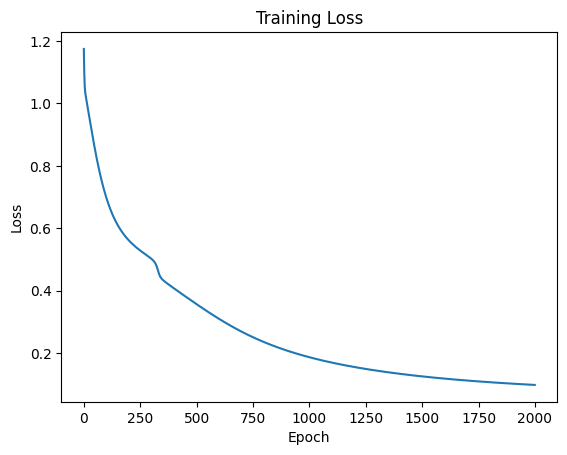

In [ ]:
import torch
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

# --------------------------------------
# load the dataset
# --------------------------------------
iris = load_iris()
X = torch.tensor(iris.data, dtype=torch.float32)
y = torch.tensor(iris.target, dtype=torch.long) # for CrossEntropyLoss, labels must be integer class ids (dtype=torch.long).

# --------------------------------------
# initialize a MLP classifier
# --------------------------------------
input_size = X.shape[1]
hidden_size = 8
output_size = 3

torch.manual_seed(0)

# TODO: define b1, W2, and b2 with the correct shapes using `torch.randn` and `requires_grad=True`,
# Note that the bias terms (b1 and b2) can be initialized to zeros, as they will be updated during training and do not require random initialization.
W1 = torch.randn(input_size, hidden_size, requires_grad=True) # W1 maps input -> hidden
b1 = torch.zeros(hidden_size, requires_grad=True)
W2 = torch.randn(hidden_size, output_size, requires_grad=True) # W2 maps hidden -> output.
b2 = torch.zeros(output_size, requires_grad=True)

print("W1 shape:", W1.shape)  # expected: [4, 8]
print("b1 shape:", b1.shape)  # expected: [8]
print("W2 shape:", W2.shape)  # expected: [8, 3]
print("b2 shape:", b2.shape)  # expected: [3]

# --------------------------------------
# implement the forward pass
# --------------------------------------
# Hint: step 1 -> hidden = sigmoid(XW1 + b1)
# Hint: step 2 -> logits = hiddenW2 + b2
# Hint: return logits (raw scores), not softmax probabilities.
def forward(x):
    # TODO: compute hidden activations with matrix multiply `@` and `torch.sigmoid`.
    hidden = torch.sigmoid(x @ W1 + b1)
    # TODO: compute output logits from the hidden layer.
    logits = hidden @ W2 + b2
    return logits

# --------------------------------------
# set up the loss and optimizer
# --------------------------------------
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD([W1, b1, W2, b2], lr=0.1) # start with SGD; you can test Adam later in optional tasks.

# --------------------------------------
# train the network
# --------------------------------------
# Hint: you may need to experiment with the learning rate and number of epochs to get good results. If the loss is not decreasing, try lowering the learning rate.
epochs = 2000
loss_history = []

for epoch in range(epochs):

    optimizer.zero_grad()
    logits = forward(X)
    loss = criterion(logits, y)
    loss.backward()
    optimizer.step() # Update the parameters.

    loss_history.append(loss.item())

    if epoch % 400 == 0:
        print(f"Epoch {epoch:4d} | Loss: {loss.item():.4f}")

# --------------------------------------
# check the learned parameter shapes
# --------------------------------------
print("\nCheck the learned parameter shapes:")
print(f"W1 shape = {tuple(W1.shape)}")
print(f"W2 shape = {tuple(W2.shape)}")
print(f"b1 shape = {tuple(b1.shape)}")
print(f"b2 shape = {tuple(b2.shape)}")

# --------------------------------------
# make predictions
# --------------------------------------
print("\nPredictions:")
with torch.no_grad():
    # TODO: compute logits for the training data.
    logits = forward(X)
    preds = torch.argmax(logits, dim=1) # For multi-class classification, predicted class = argmax(logits).
    for x, target, pred in zip(X, y, preds):
        print(f"Input: {x.tolist()} | Target: {int(target.item())} | Pred: {int(pred.item())}")

# --------------------------------------
# plot the loss curve
# --------------------------------------
# Hint: if loss is very noisy or increases, try lowering learning rate.
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()



### Question Set 1: Reflection on the Implementation (Submission is Required)
Investigate the above code, answer the following questions:
1. what is the purpose of `torch.manual_seed()`?
2. Research at least three other loss functions available in PyTorch. For each one:
- State its PyTorch class/function name.
- Describe a suitable use case.
- Explain how it differs from the loss function used in this exercise.
3. For the line `loss = criterion(logits, y)`, answer the following:
- What are the inputs to criterion?
- What does the output represent?
- Why do we compare the model outputs (logits) with the true labels (y)?
4. What is the difference between:
- logits,
- probabilities,
- predicted labels?
Give an example showing how one can be transformed into another.

---


### TODO: Answers of Question Set 1

Please write your answers below. Be clear and concise.

1.The purpose of torch.manual_seed() is that it is used to set a fixed value for the PyTorch random number generator. This ensures that random values such as torch.randn(),which is used to initialise weights (W1 and W2), produces the same value each time the code is run. Without this process the weights would be different, which makes a comparison test diffcult.

2a. Loss Function 1: Binary Classification

PyTorch class: nn.BCEWithLogitsLoss()

Binary classification problems require the model to predict one or two outcomes, for example not spam or spam. As mentioned in the week 2 lecture, binary classification is used to predict two classes for example 0 or 1 and the model outputs a probability of belonging to class 1. The formula for Binary Cross Entropy is: L = -1/n Σ[yᵢ log(ŷᵢ) + (1 - yᵢ)log(1 - ŷᵢ)]. The loss fucntion used in this exercise is multi class classification. Multi class classification differs as it handles multiple classes and and the model outputs a probability distribution over all classes, where as binary classification only handles two classes and the model outputs a single probability belonging to each class. Also binary classfifcation uses the activation function sigmoid where as multiclass classification uses softmax.


2b. Loss Function 2: MSE (Regression)

PyTorch class: nn.MSELoss()

MSE (Mean Squared Error) is a regression task that predcits a continous value for example house prices. MSE is used to measure the squared difference between the predicted and true values. The formula for this loss function is: L = Σ(yᵢ - ŷᵢ)² / n. The key difference between the two loss functions is that multi class classification is a classification task used for predicting a discrete value, where as MAE is a regression task used for predicting continous values. Another difference is that MAE uses the activation function linear where as the other uses softmax. Also multiclass classfifcation uses logarithms to measures how incorrect the class prediction is and MAE uses squared differences to see how far the numerical prediction is.

2c. Loss Function 3: MAE (Regression)

PyTorch class: nn.L1Loss()

Simarly to MSE, MAE (Mean Absolute Error) is also a regression task used to predict continous values. However it is used to measure the absolute difference between the predicted and true values rather than squaring the difference.The formula given in week to for MAE is: L = Σ|yᵢ - ŷᵢ| / n. The difference between multiclass classification and MAE is that MAE is a regression task that uses the activation function linear similar to MSE, where as in this excersice a classification task was used and its activiation function is softmax.

3.loss = criterion(logits, y)

The line above consists of two inputs, logits and y. Logits is the raw ouput found in the linear layer of the network, in this lab the shape is [150,3]. y is the true class label, in this lab they are stored as integers to represent the three Iris species (setosa, versicolor, and virginica). For the loss function to work properly, y must be a torch.long.

In this excersice the output is a sinlge scalar value which is represented by the loss fucntion cross entropy loss. The formula for this loss fucntion is L = -(1/n) ΣΣ yᵢₖ log(ŷᵢₖ), however a simplified explanaition is by looking at probability of the correct class, removing the -log and then average across all instances in the dataset. Using week 1 lecture interpretation if the loss is high the model is making many mistakes however a low loss suggests that the model is performing well and closer to prediciting the true label.

The reason why we compare the model outputs (logits) and with the true labels (y) is because the loss allows us to compare the prediction and what was actually correct, without this value there isnt anything to compare it against. Lecture 1 states that the loss fucntion measures the prediction error on a single training example, therefore the predicition error is crucial during the training process. Also, week 2 states that for the model to make a more accurate prediction we need train the model to learn the best parameters (bias and weights). Therefore without the comparison of logits and y, weight would not be updated and the network would not be able to learn and improve.

4.Logits is the raw score output produced by the final linear layer of the neural network. It is applied before any activation function is applied. In this lab excersice logits is used here" return logits (raw scores), the forward function returns logits shape (150,3), which gives us one raw number per class per sample.

Probabilities is the results of logits when it goes through the softmax activation function. As mentioned in lecture 2 softmax converts the raw score into class probability and each value is between 0 and 1 and sum up to 1.

Predicted label is the single class that indicates which iris species (Setosa, Versicolor, and Virginica) the model believes the sample belongs to. This is collected by calculating the argmax of the probabilities or the logits.

Example using the lab excersice:

Step 1: logits = forward(x)

Step 2: probs = torch.softmax(logits, dim=0)

Step 3: preds = torch.argmax(logits, dim=1)

### Question Set 2: Reflection on the Training Process (submission is required)
We implemented the training processing using the code below:
```python
optimizer.zero_grad()  
logits = forward(X)    
loss = criterion(logits, y)  
loss.backward()        
optimizer.step()       
```
For each line in the training loop:
- Explain what the line does.
- Explain why it is needed.
- Explain what would happen if the line were removed or executed in the wrong order.
Use reliable sources (e.g., PyTorch documentation, tutorials, or textbooks) to support your explanations.

Also answering the following questions:
1. Why do trainable model parameters typically have `requires_grad=True`?
2. What exactly is being updated when optimizer.step() is called?
3. Why do we call `optimizer.zero_grad()` before `loss.backward()`?
4. Why are `logits` (raw scores) passed to `criterion` instead of predicted labels?
5. What information does `loss.backward()` compute, and where is it stored?
6. Why must `optimizer.step()` happen after gradients are computed?
7. What would happen if loss.backward() were called twice without first calling optimizer.zero_grad()?



### TODO: Answers of Question Set 2

Please write your answers below. Be clear and concise.

optimizer.zero_grad()
- According to Pytorch documentation it resets the gradients of all optimized torch.Tensor's. Instead of setting to zero, it sets the gradient to None. This will generate a lower memory footprint and improve performance.
- This Line is needed as PyTorch's engine adds gradients by default instead of overwriting them. Lecture 3 states that the gradients are stored in each parameter's .grad attribute for example b.grad and w.grad.
- Without this line, the update direction would be affected as the gradients from the prior epoch would add to the gradients current epoch, which increases each iteration.

logits = forward(X)   
- This line is used to run the forward pass. As seen in the excersice above the input (x) goes through the network ( hidden = torch.sigmoid(x @ W1 + b1) the the logits (logits = hidden @ W2 + b2) in order to get the raw score.
- This line is needed as it allows the model to create predictions. Lecture 3 states that forward pass is the first step in backpropagation, it inputs the data through the network, computes the weighted sum, adds bias and adds an activation function. Also in PyTorch the forward pass each operation is a node in a graph, which records and stores the results for later use.
- Without the use of the logits = forward (x), the rest of the code for example loss = criterion would not run and would cause an error.

loss = criterion(logits, y)
- This line computes the loss number of the model's prediction. nn.CrossEntropyLoss is used here to predict the raw ouputs (logits) to the true label (y).
- This line is needed and crucial as it tells us how incrorrect the current predictions are.
- Without this line the training process will not start as gradient wont be computed.

loss.backward()  
- Lecture 3 states that loss.backward() triggers the backpropagation.
- This is needed as is it uses the chain rule to compute the gradient automatically.
- This is needed as the results of this line is stored in each parameters .grad attribute, therefore without it gradients would be incorrect and the model wont learn.      

optimizer.step()
- PyTorch documentation states that this line does a single optimization step to update parameters.
- It is needed as it improves the model. Lecture 2 states that by moving in the opposite direction of the gradient we minimise errors and update model parameters
- If this step was removed we would not be able to compute the gradient, the loss would not decrease and the weights wouldnt change.

1. requires_grad=True allows PyTorch's engine to record each operation performed. This step allows PyTorch to keep a note of the tensor's memory and allows the gradient to be updated.

2. optimizer.step() updates the values inside each trainable parameter tensor. For example in this task it would be W1, b1, W2, b2.

3. optimizer.zero_grad() is called before loss.backward() as the grad is calculated first by PyTorch, if loss.backward() is called first then every epoch gradient would be added onto the prior one which created incorrect gradient values.

4. Logits are passed to critera instead of predicted labels as the loss function (nn.CrossEntropyLoss) needs the complete and raw score to compute a differentiable loss. However passing through the predicted label would not give us a gradient as argmax is not differentiable.

5. loss.backward() computes the derivative of the loss in each trainable parameter (weights and bias). As stated in lecture 3 this is then stored in each parameters .grad attribute for example W1.grad.

6. optimizer.step() happens after the gradients computed as before it updates it needs to to know the number in every parameter's .grad attribute otherwise the .grad would be zero and would not know in which direction to update.

7. The second .backward() gardient would be added ontop of the first gradient without replacing them. If the the gradient is not cleared using .zero_grad they will continue accumulating and update incorrectly. This would result to an increase in loss instead of a decrease in loss.

### TODO: Workflow (Submission is Required)
Fill in the blanks below to describe how the Task A code is structured:

The Task A code follows a standard PyTorch training workflow.

First, we load the dataset and convert it into tensor format.
Next, we initialize model parameters using random (torch.randn) initialization.
Then we define the forward function to compute predictions from the model.
After that, we set up the loss (criterion) function and the optimizer used for updating parameters.

During training, we repeat a training (epoch) loop where we:
- clear gradients using optimizer.zero_grad(),
- compute predictions using forward (x),
- calculate the loss (criterion(logits,y),
- compute gradients using loss.backward(),
- and update parameters using optimizer.step().

After training, we evaluate the model by:
- turning off gradient tracking using torch.no_grad(),
- computing model outputs on the data,
- and selecting predicted classes using torch.argmax(logits,dim=1).

Finally, we compare the predicted labels with the target (y) labels to measure performance.

## Task B: Rebuild the Model with `nn.Module`

Now you will rewrite the same neural network using PyTorch's module API.

This second big task has the same learning goal as Task A, but now you will build the model in the standard PyTorch style.

Complete the TODOs. Tutorial code an be found in the Pytorch documentation for building a simple feedforward neural network: https://pytorch.org/tutorials/beginner/blitz/neural_networks_tutorial.html

X_tensor_demo shape: torch.Size([150, 4])
y_tensor_demo shape: torch.Size([150])
Epoch    0 | Loss: 1.1258
Epoch  400 | Loss: 0.3306
Epoch  800 | Loss: 0.1703
Epoch 1200 | Loss: 0.1175
Epoch 1600 | Loss: 0.0949

Inspect the learned parameters:
hidden weights: tensor([[-0.3790, -0.5740,  1.3607,  0.9061],
        [ 1.5276,  1.0149, -1.9969, -2.3152],
        [ 0.0055,  1.3172, -0.7333, -1.1938],
        [-0.1464, -1.0861,  1.5496,  0.5601],
        [-0.7391, -1.1931,  1.3510,  1.4882],
        [ 1.0576,  1.0657, -1.6894, -1.4731],
        [ 0.5587,  0.7745, -1.2945, -0.8901],
        [ 0.4393,  0.3259, -0.2349, -0.1165]])
hidden bias: tensor([-0.6751,  0.9657, -0.1204, -0.5686, -0.6057,  0.5798, -0.0083,  0.2850])
output weights: tensor([[-2.1052,  1.2041,  1.8688, -2.5046, -1.9590,  2.1104,  2.2210, -0.0817],
        [ 0.7218,  2.0453, -0.3148,  0.9722, -1.1459,  0.6070, -0.2709, -0.2424],
        [ 1.1833, -3.1972, -1.5594,  1.4771,  2.4475, -2.9291, -1.7339,  0.1993]])
output bias: t

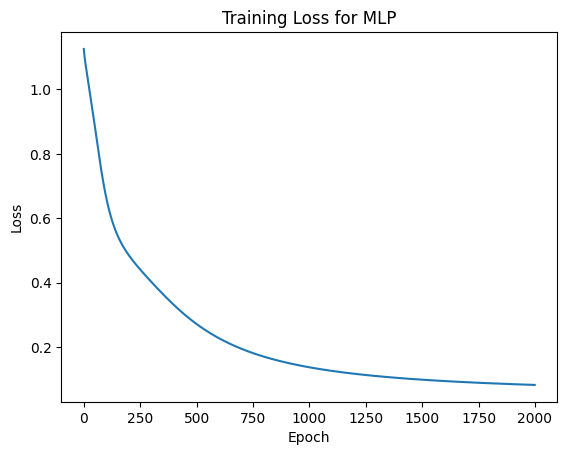

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

# --------------------------------------
# load the dataset
# --------------------------------------
iris = load_iris()
X_tensor_demo = torch.tensor(iris.data, dtype=torch.float32)
y_tensor_demo = torch.tensor(iris.target, dtype=torch.long)

# Quick checks
print("X_tensor_demo shape:", X_tensor_demo.shape)
print("y_tensor_demo shape:", y_tensor_demo.shape)

# --------------------------------------
# define the model class and the forward pass
# --------------------------------------
# Hint: `__init__` defines layers, `forward` defines data flow.
# Hint: use `nn.Linear` for layers and `nn.Sigmoid` for hidden activation.
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        # TODO: define hidden layer, to match with Task A, hidden layer should have 8 units and take input of size 4.
        self.hidden = nn.Linear(4, 8)
        # TODO: define output layer, output layer should produce logits for 3 classes.
        self.output = nn.Linear(8, 3)
        # TODO: define activation function, for hidden layer we will use sigmoid activation function.
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # TODO: implement forward pass in 3 steps:
        # 1) hidden linear
        x = self.hidden(x)
        # 2) sigmoid activation
        x = self.sigmoid(x)
        # 3) output linear (logits)
        logits = self.output(x)
        return logits

        ...

# --------------------------------------
# create model, loss, and optimizer
# --------------------------------------
# Hint: use the same loss and optimizer type as Task A first.
# TODO: instantiate model
model = MLP()
# TODO: define criterion
criterion = nn.CrossEntropyLoss()
# TODO: define optimizer
optimizer = optim.SGD(model.parameters(), lr=0.1)

# --------------------------------------
# train the module
# --------------------------------------
# Hint: this loop should look almost identical to Task A.
epochs = 2000
loss_history_tensor = []

for epoch in range(epochs):
    # TODO: forward pass to get logits
    logits = model(X_tensor_demo)
    # TODO: compute loss
    loss = criterion(logits, y_tensor_demo)
    # TODO: store loss value in loss_history_tensor
    loss_history_tensor.append(loss.item())
    # TODO: zero gradients
    optimizer.zero_grad()
    # TODO: backward pass
    loss.backward()
    # TODO: optimizer step
    optimizer.step()

    if epoch % 400 == 0:
        print(f"Epoch {epoch:4d} | Loss: {loss.item():.4f}")

print("\nInspect the learned parameters:")
# TODO: print hidden and output weights/biases using `.detach()`
print("hidden weights:", model.hidden.weight.detach())
print("hidden bias:", model.hidden.bias.detach())
print("output weights:", model.output.weight.detach())
print("output bias:", model.output.bias.detach())
# --------------------------------------
# make predictions with the module
# --------------------------------------
# Hint: compare a few predictions manually to build intuition.
print("\nPredictions from module model:")
with torch.no_grad():
    # TODO: get logits from model
    logits = model(X_tensor_demo)
    # TODO: convert logits to predicted classes using argmax
    preds = torch.argmax(logits, dim=1)
    for x, target, pred in zip(X_tensor_demo, y_tensor_demo, preds):
        print(f"Input: {x.tolist()} | Target: {int(target.item())} | Pred: {int(pred.item())}")

# --------------------------------------
# plot the loss curve
# --------------------------------------
# Hint: compare this curve against Task A to check consistency.
plt.plot(loss_history_tensor)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss for MLP")
plt.show()

### TODO: Reflection and Comparison (submission is required)

Fill-in the blanks below for a comparison between the two implementations:

1. In Task A, model parameters are created manually using torch.randn and torch.zeros with requires_grad=True, while in Task B they are created automatically inside nn.Linear.
2. In Task B, the model architecture is defined using nn.Module (MLP class with forward and init), whereas in Task A it is defined by explicitly writing operations step-by-step.
3. In Task A, weights and biases are stored as standalone tensor (W1, b1, W2, b2)variables, while in Task B they are stored inside an nn.Module object.
4. The forward pass in Task A is written explicitly using operations like matrix multiplication, while in Task B it is handled by the forward method.
5. The mathematical computation in both Task A and Task B is same, but the implementation level is manual in Task A and abstracted in Task B.
6. In Task A, we manually compute gradients using loss.backward(), while in Task B this is handled automatically by PyTorch autograd.
7. The parameter update step in Task A is done manually, but in Task B it is performed using optimizer.step().
8. The operation nn.Linear in Task B internally performs the same computation as hidden @ W2 + b2 and x @ W1 and b1 in Task A.
9. Task B has a shorter training loop because PyTorch automates parameter (model.parameters())and forward pass (model(X_tensor_demo)).
10. The main advantage of Task A is higher control, while the main advantage of Task B is higher readability.


### Optional Tasks (submission is NOT required)

- change the hidden size and see what happens,
- try `optim.Adam` instead of `optim.SGD`,
- add an accuracy calculation after training,
- compare the loss curve for different learning rates.
- create mini-batches for Iris and train the model using them. Then compare the training behavior with full-batch learning.

X_tensor_demo shape: torch.Size([150, 4])
y_tensor_demo shape: torch.Size([150])

Changing hidden size
Hidden size: 4 | Final Loss: 0.1056
Hidden size: 8 | Final Loss: 0.0821
Hidden size: 16 | Final Loss: 0.0759
Epoch    0 | Loss: 1.1069
Epoch  400 | Loss: 0.5543
Epoch  800 | Loss: 0.3315
Epoch 1200 | Loss: 0.1889
Epoch 1600 | Loss: 0.1240

Inspect the learned parameters:
hidden weights: tensor([[-0.7355, -1.1293,  1.4055,  2.0605],
        [ 0.5745,  0.5324, -1.0094, -1.0784],
        [-0.0921,  1.5264, -1.3205, -1.3354],
        [ 0.3743, -1.4695,  0.5141,  1.1738],
        [ 0.5487,  0.6166, -1.7565, -1.7500],
        [ 0.0155, -1.2151,  1.4074,  1.3515],
        [ 1.1523,  1.6597, -2.0833, -2.3105],
        [ 0.5749,  0.5518, -0.8913, -1.6073]])
hidden bias: tensor([-2.3102,  1.2115,  0.6153, -0.8559,  0.9164, -1.0417,  1.8601,  1.3185])
output weights: tensor([[-0.9931,  1.2607,  1.7420, -1.7050,  1.2201, -1.3062,  0.9416,  1.1098],
        [-1.6057,  1.1137, -0.4485,  0.2702, -1.

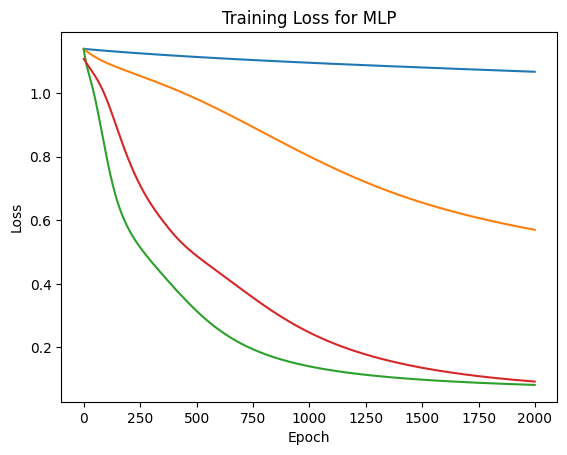

In [ ]:
#OPTIONAL TASK: I used the same excersice in Task B however i made slight changes to the code. I changed the hidden size, changed SGD for Adam, calculated the accuracy, compared different learning rates and created mini batched of the iris dataset to train the model.

import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
# Optional Task: Imported data loader to create mini batched, from lab 3
from torch.utils.data import DataLoader, TensorDataset

# --------------------------------------
# load the dataset
# --------------------------------------
iris = load_iris()
X_tensor_demo = torch.tensor(iris.data, dtype=torch.float32)
y_tensor_demo = torch.tensor(iris.target, dtype=torch.long)

# Quick checks
print("X_tensor_demo shape:", X_tensor_demo.shape)
print("y_tensor_demo shape:", y_tensor_demo.shape)

# --------------------------------------
# define the model class and the forward pass
# --------------------------------------
# Hint: `__init__` defines layers, `forward` defines data flow.
# Hint: use `nn.Linear` for layers and `nn.Sigmoid` for hidden activation.
class MLP(nn.Module):
    def __init__(self, hidden_size=8): # OPTIONAL TASK: Hidden size is changed into a parameter
        super().__init__()
        # OPTIONAL TASK: 8 has changed to a hidden variable.
        self.hidden = nn.Linear(4, hidden_size)
        # OPTIONAL TASK: output changed to hidden size.
        self.output = nn.Linear(hidden_size, 3)
        # TODO: define activation function, for hidden layer we will use sigmoid activation function.
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # TODO: implement forward pass in 3 steps:
        # 1) hidden linear
        x = self.hidden(x)
        # 2) sigmoid activation
        x = self.sigmoid(x)
        # 3) output linear (logits)
        logits = self.output(x)
        return logits

        ...
# Optional Task: The following lines of code is to compare Task B hidden size of 8 and what i have changed the hidden size which is 4 and 16.
print("\nChanging hidden size")
for hidden_size in [4, 8, 16]:
    torch.manual_seed(0)
    model_hs = MLP(hidden_size=hidden_size)
    criterion_hs = nn.CrossEntropyLoss()
    optimizer_hs = optim.SGD(model_hs.parameters(), lr=0.1)
    for epoch in range(2000):
        logits = model_hs(X_tensor_demo)
        loss = criterion_hs(logits, y_tensor_demo)
        optimizer_hs.zero_grad()
        loss.backward()
        optimizer_hs.step()
    print(f"Hidden size: {hidden_size} | Final Loss: {loss.item():.4f}")


# --------------------------------------
# create model, loss, and optimizer
# --------------------------------------
# Hint: use the same loss and optimizer type as Task A first.
# TODO: instantiate model
model = MLP()
# TODO: define criterion
criterion = nn.CrossEntropyLoss()
# OPTIONAL TASK: Change SGC for Adam, Adam uses a lower lr.
optimizer = optim.Adam(model.parameters(), lr=0.001)

# --------------------------------------
# train the module
# --------------------------------------
# Hint: this loop should look almost identical to Task A.
epochs = 2000
loss_history_tensor = []

for epoch in range(epochs):
    # TODO: forward pass to get logits
    logits = model(X_tensor_demo)
    # TODO: compute loss
    loss = criterion(logits, y_tensor_demo)
    # TODO: store loss value in loss_history_tensor
    loss_history_tensor.append(loss.item())
    # TODO: zero gradients
    optimizer.zero_grad()
    # TODO: backward pass
    loss.backward()
    # TODO: optimizer step
    optimizer.step()

    if epoch % 400 == 0:
        print(f"Epoch {epoch:4d} | Loss: {loss.item():.4f}")

print("\nInspect the learned parameters:")
# TODO: print hidden and output weights/biases using `.detach()`
print("hidden weights:", model.hidden.weight.detach())
print("hidden bias:", model.hidden.bias.detach())
print("output weights:", model.output.weight.detach())
print("output bias:", model.output.bias.detach())
# --------------------------------------
# make predictions with the module
# --------------------------------------
# Hint: compare a few predictions manually to build intuition.
print("\nPredictions from module model:")
with torch.no_grad():
    # TODO: get logits from model
    logits = model(X_tensor_demo)
    # TODO: convert logits to predicted classes using argmax
    preds = torch.argmax(logits, dim=1)
    for x, target, pred in zip(X_tensor_demo, y_tensor_demo, preds):
        print(f"Input: {x.tolist()} | Target: {int(target.item())} | Pred: {int(pred.item())}")

# OPTIONAL TASK: Accuracy calculation added to see how many true and predicted labels match
print("\n Accuracy Calculation")
with torch.no_grad():
     logits = model(X_tensor_demo)
     preds = torch.argmax(logits, dim=1)
     correct = (preds == y_tensor_demo).sum().item()
     total = y_tensor_demo.size(0)
     accuracy = correct / total * 100
     print(f"Accuracy: {correct}/{total} = {accuracy:.1f}%")

# OPTIONAL TASK: Comparing the loss curve for different learning rates.
print("\n Comparing Different Learning Rates")
learning_rates = [0.001, 0.01, 0.1]
plt.figure()
for lr in learning_rates:
    torch.manual_seed(0)
    model_lr = MLP(hidden_size=8)
    optimizer_lr = optim.SGD(model_lr.parameters(), lr=lr)
    criterion_lr = nn.CrossEntropyLoss()
    history_lr = []
    for epoch in range(2000):
        logits_lr = model_lr(X_tensor_demo)
        loss_lr = criterion_lr(logits_lr, y_tensor_demo)
        history_lr.append(loss_lr.item())
        optimizer_lr.zero_grad()
        loss_lr.backward()
        optimizer_lr.step()
    plt.plot(history_lr, label=f"lr={lr}")
# --------------------------------------
# plot the loss curve
# --------------------------------------
# Hint: compare this curve against Task A to check consistency.
plt.plot(loss_history_tensor)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss for MLP")
plt.show()